## Predictive-Maintenance-ML-Project

# 1. Problem Understanding

## Business Problem

We have machine operating data and want to predict whether a machine will experience a failure.

Our model should predict:

**Machine Failure**

- `0` → No Failure
- `1` → Failure

## ML Problem

**Binary Classification**

## Objective

Predict machine failure **before it occurs**.

## Primary Metrics

For this project, we will **not automatically use accuracy** as the primary evaluation metric.

We will first investigate the class distribution and determine whether the dataset is imbalanced. Based on the business requirements, we will evaluate the following metrics:

- **F1 Score**
- **Recall**
- **Precision**
- **ROC-AUC**

For predictive maintenance, **Recall is particularly important** because missing an actual machine failure can be more costly than generating a false alarm.

Therefore, the final model-selection metric will be decided after examining the **class imbalance and business trade-offs** between false positives and false negatives.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('../data/ai4i2020.csv')

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.shape

(10000, 14)

#### Basic Dataset Understanding

In [6]:
df.shape[0]

10000

In [7]:
df.shape[1]

14

In [8]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [9]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [10]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
df.describe(include="object")

,Product ID,Type
count,10000,10000
unique,10000,3
top,L57163,L
freq,1,6000


#### Numerical and Categorical Columns

In [12]:
numerical_cols = []
categorical_cols = []
for col in df.columns:
    if(df[col].dtype == "O"):categorical_cols.append(col)
    else:numerical_cols.append(col)

In [13]:
numerical_cols

['UDI',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [14]:
categorical_cols

['Product ID', 'Type']

#### Identify Target

In [15]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [16]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

### This is an imbalanced dataset

### Data Quality Checks

In [17]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
for column in categorical_cols:
    print(column, df[column].unique())

Product ID ['M14860' 'L47181' 'L47182' ... 'M24857' 'H39412' 'M24859']
Type ['M' 'L' 'H']


In [20]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

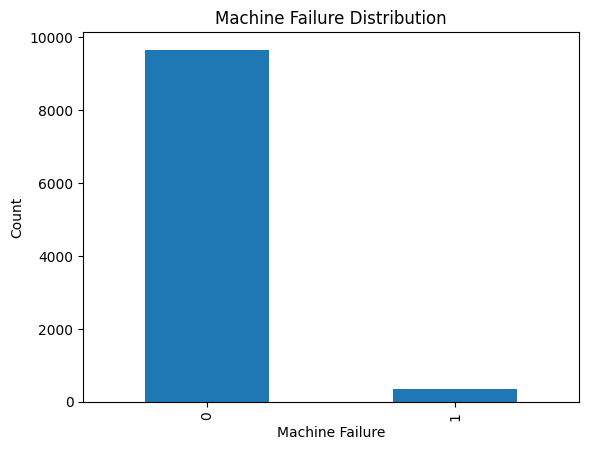

In [21]:
df["Machine failure"].value_counts().plot(kind="bar")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

Observation:

The target classes are imbalanced, with non-failure
instances significantly outnumbering failure instances.

Therefore, accuracy alone should not be used for model
selection.

#### Exploratory Data Analysis

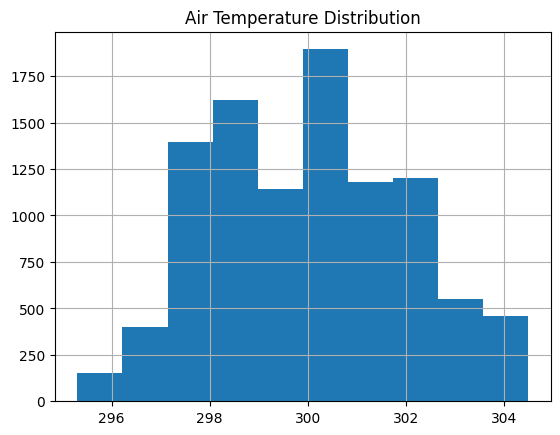

In [22]:
df["Air temperature [K]"].hist()
plt.title("Air Temperature Distribution")
plt.show()

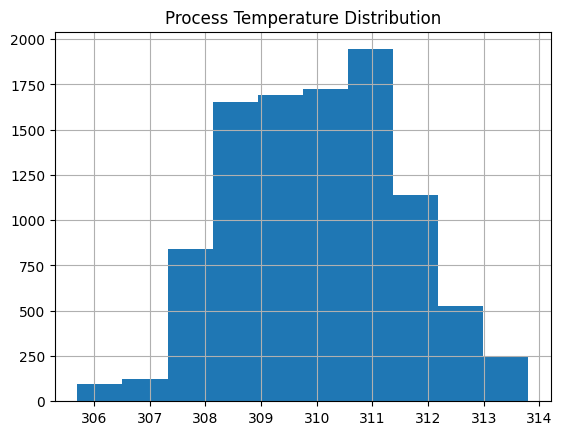

In [23]:
df["Process temperature [K]"].hist()
plt.title("Process Temperature Distribution")
plt.show()

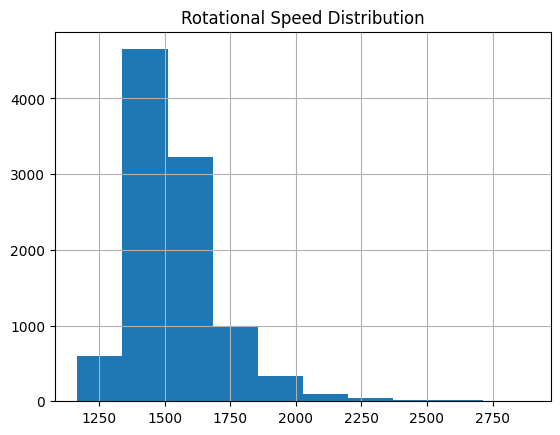

In [24]:
df["Rotational speed [rpm]"].hist()
plt.title("Rotational Speed Distribution")
plt.show()

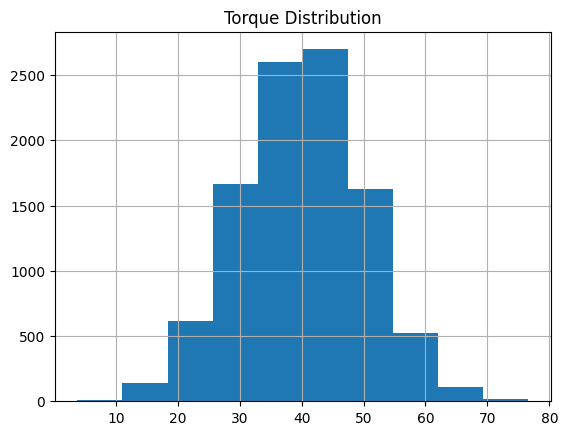

In [25]:
df["Torque [Nm]"].hist()
plt.title("Torque Distribution")
plt.show()

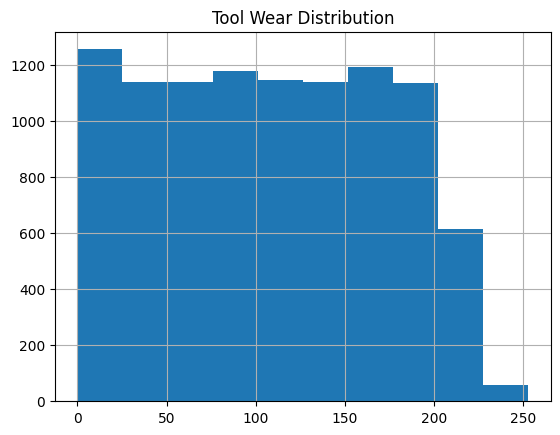

In [26]:
df["Tool wear [min]"].hist()
plt.title("Tool Wear Distribution")
plt.show()

##### Failure vs Feature Analysis

In [27]:
df.groupby("Machine failure")["Torque [Nm]"].mean()

Machine failure
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64

In [28]:
df.groupby("Machine failure")["Air temperature [K]"].mean()

Machine failure
0    299.973999
1    300.886431
Name: Air temperature [K], dtype: float64

In [29]:
df.groupby("Machine failure")["Process temperature [K]"].mean()

Machine failure
0    309.995570
1    310.290265
Name: Process temperature [K], dtype: float64

In [30]:
df.groupby("Machine failure")["Rotational speed [rpm]"].mean()

Machine failure
0    1540.260014
1    1496.486726
Name: Rotational speed [rpm], dtype: float64

In [31]:
df.groupby("Machine failure")["Process temperature [K]"].mean()

Machine failure
0    309.995570
1    310.290265
Name: Process temperature [K], dtype: float64

In [32]:
df.groupby("Machine failure")["Torque [Nm]"].mean()

Machine failure
0    39.629655
1    50.168142
Name: Torque [Nm], dtype: float64

In [33]:
pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
)

Machine failure,0,1
Type,,
H,0.979063,0.020937
L,0.960833,0.039167
M,0.972306,0.027694


##### Outlier Investigation

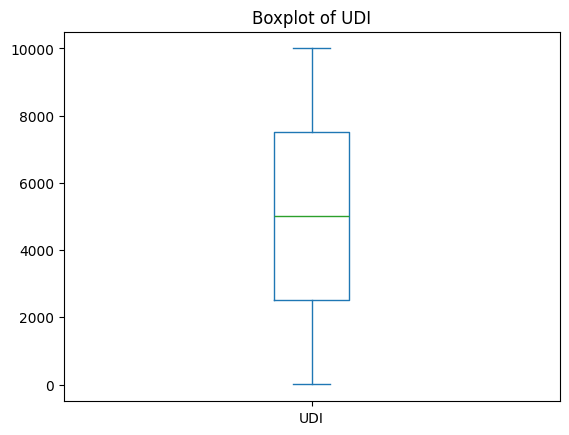

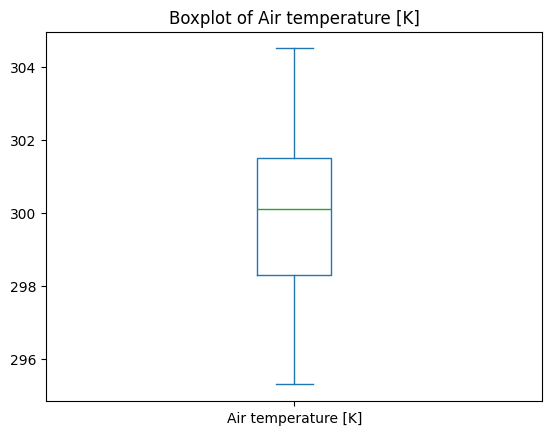

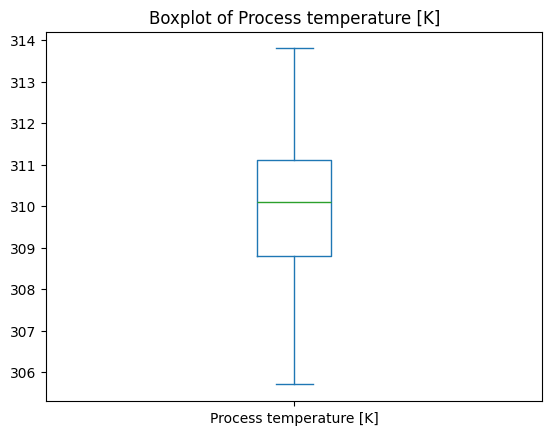

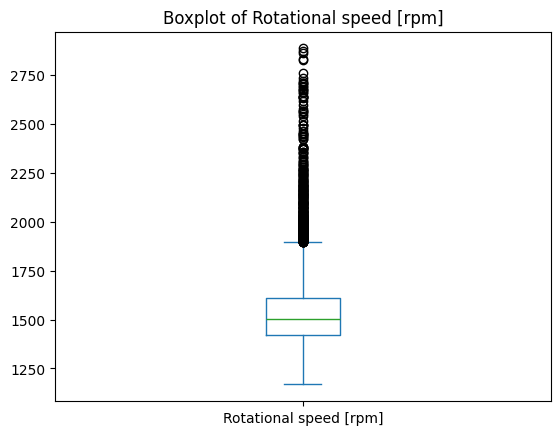

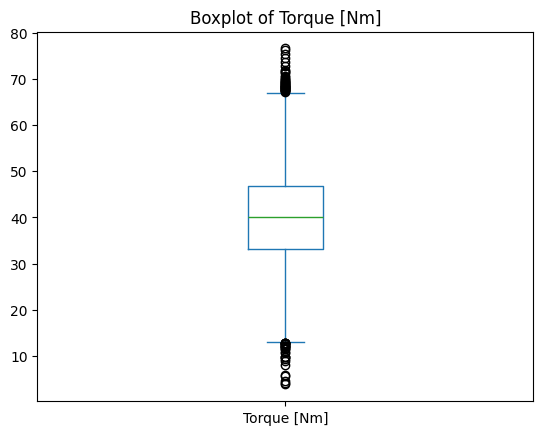

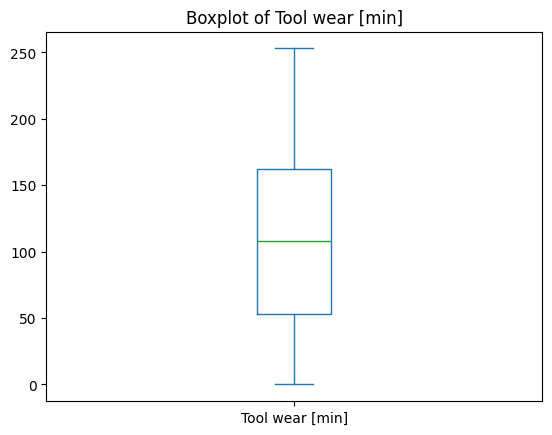

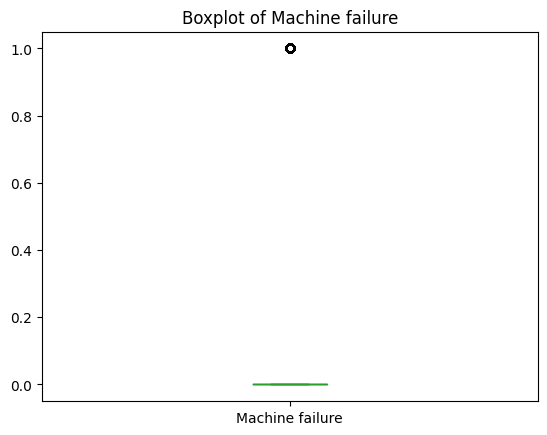

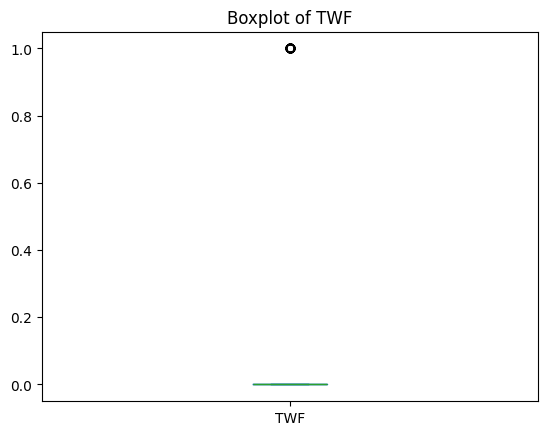

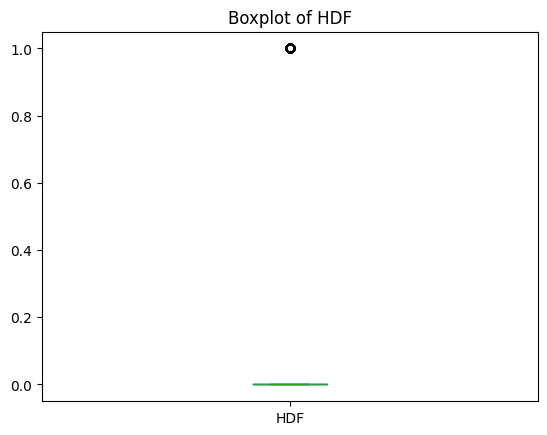

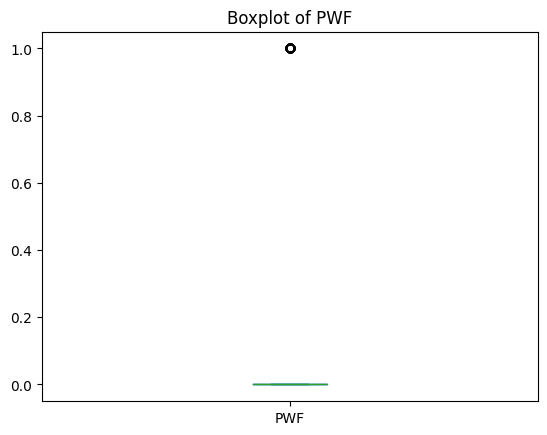

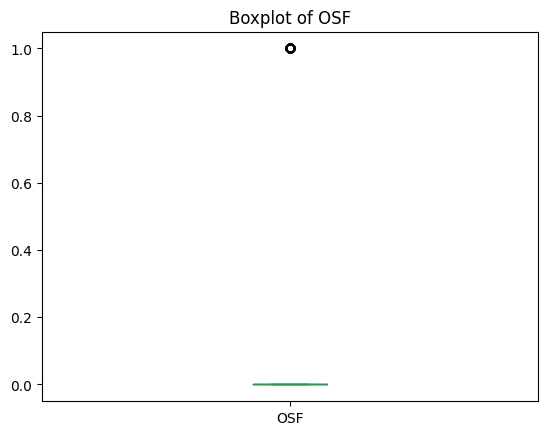

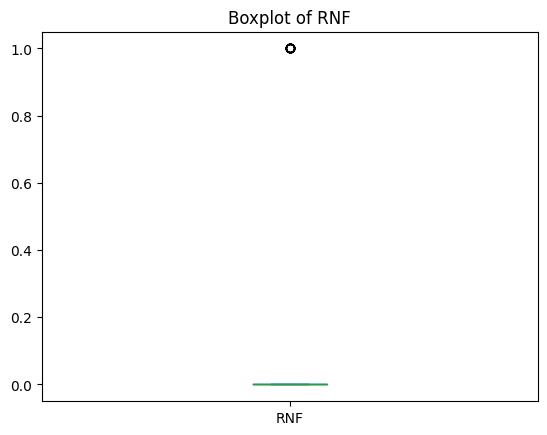

In [34]:
for col in numerical_cols:
    df[col].plot(kind="box")
    plt.title(f"Boxplot of {col}")
    plt.show()

In [35]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [36]:
df.drop(columns=[ 'UDI','TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF','Product ID'],axis=1,inplace=True)

In [37]:
raw_df = df.copy()

In [38]:
raw_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


#### engineered feature.

In [39]:
## This can represent thermal stress/load.
df["Temperature Difference"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

In [40]:
df["Power Proxy"] = (
    df["Rotational speed [rpm]"]
    * df["Torque [Nm]"]
)

In [41]:
df["Torque Tool Wear"] = (
    df["Torque [Nm]"]
    * df["Tool wear [min]"]
)

In [42]:
df["Speed Torque Ratio"] = (
    df["Rotational speed [rpm]"]
    / (df["Torque [Nm]"] + 1e-6)
)

In [43]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference,Power Proxy,Torque Tool Wear,Speed Torque Ratio
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.0,36.238317
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,138.9,30.410367
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,247.0,30.323886
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,276.5,36.278480
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,360.0,35.199999


In [44]:
numerical_cols = []
categorical_cols = []
for col in df.columns:
    if(df[col].dtype == "O"):categorical_cols.append(col)
    else:numerical_cols.append(col)

In [45]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Temperature Difference', 'Power Proxy',
       'Torque Tool Wear', 'Speed Torque Ratio'],
      dtype='object')

In [46]:
numerical_cols

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'Temperature Difference',
 'Power Proxy',
 'Torque Tool Wear',
 'Speed Torque Ratio']

In [47]:
categorical_cols

['Type']

In [48]:
target_column = "Machine failure"

X = df.drop(columns=[target_column])
y = df[target_column]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference', 'Power Proxy', 'Torque Tool Wear', 'Speed Torque Ratio']
Categorical: ['Type']


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [52]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [53]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_pipeline",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical_pipeline",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [54]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

In [55]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64


In [56]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_transformed,
    y_train
)

In [57]:
print("After SMOTE:")
print(y_train_resampled.value_counts())

After SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [58]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)


def evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    models
):

    model_report = {}

    for model_name, model in models.items():

        print(f"\n{'=' * 20} {model_name} {'=' * 20}")

        # -----------------------------
        # Train model
        # -----------------------------
        model.fit(
            X_train,
            y_train
        )

        # -----------------------------
        # Predictions
        # -----------------------------
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # -----------------------------
        # F1 Score
        # -----------------------------
        train_f1 = f1_score(
            y_train,
            y_pred_train
        )

        test_f1 = f1_score(
            y_test,
            y_pred_test
        )

        # -----------------------------
        # Precision
        # -----------------------------
        train_precision = precision_score(
            y_train,
            y_pred_train
        )

        test_precision = precision_score(
            y_test,
            y_pred_test
        )

        # -----------------------------
        # Recall
        # -----------------------------
        train_recall = recall_score(
            y_train,
            y_pred_train
        )

        test_recall = recall_score(
            y_test,
            y_pred_test
        )

        # -----------------------------
        # ROC-AUC
        # -----------------------------
        train_probability = model.predict_proba(X_train)[:, 1]
        test_probability = model.predict_proba(X_test)[:, 1]

        train_roc_auc = roc_auc_score(
            y_train,
            train_probability
        )

        test_roc_auc = roc_auc_score(
            y_test,
            test_probability
        )

        # -----------------------------
        # Store results
        # -----------------------------
        model_report[model_name] = {

            "train_f1": train_f1,
            "test_f1": test_f1,

            "train_precision": train_precision,
            "test_precision": test_precision,

            "train_recall": train_recall,
            "test_recall": test_recall,

            "train_roc_auc": train_roc_auc,
            "test_roc_auc": test_roc_auc
        }

    return model_report

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBClassifier


models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    # "XGBoost": XGBClassifier(
    #     n_estimators=200,
    #     learning_rate=0.05,
    #     max_depth=5,
    #     random_state=42,
    #     eval_metric="logloss"
    # )
}

In [60]:
model_report = evaluate_model(
    X_train_resampled,
    X_test_transformed,
    y_train_resampled,
    y_test,
    models
)


==================== Logistic Regression ====================

==================== Decision Tree ====================

==================== Random Forest ====================

==================== Gradient Boosting ====================


In [61]:
results_df = pd.DataFrame(model_report).T

results_df.sort_values(
    by="test_f1",
    ascending=False
)

,train_f1,test_f1,train_precision,test_precision,train_recall,test_recall,train_roc_auc,test_roc_auc
Random Forest,1.000000,0.735484,1.000000,0.655172,1.000000,0.838235,1.000000,0.978984
Decision Tree,1.000000,0.662651,1.000000,0.561224,1.000000,0.808824,1.000000,0.893283
Gradient Boosting,0.974266,0.605128,0.971322,0.464567,0.977229,0.867647,0.996882,0.977534
Logistic Regression,0.863115,0.288462,0.850433,0.172414,0.876181,0.882353,0.936492,0.940902


In [62]:
results_df

,train_f1,test_f1,train_precision,test_precision,train_recall,test_recall,train_roc_auc,test_roc_auc
Logistic Regression,0.863115,0.288462,0.850433,0.172414,0.876181,0.882353,0.936492,0.940902
Decision Tree,1.000000,0.662651,1.000000,0.561224,1.000000,0.808824,1.000000,0.893283
Random Forest,1.000000,0.735484,1.000000,0.655172,1.000000,0.838235,1.000000,0.978984
Gradient Boosting,0.974266,0.605128,0.971322,0.464567,0.977229,0.867647,0.996882,0.977534
